# Plot Zero-Variance extrapolation - 1D chain L = 20

In [1]:
import glob
import os
import sys

In [2]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
%load_ext autoreload
%autoreload 2

from src.utils import *
from src.MC_extrapol import run_monte_carlo_extrapolation
from src.plot.plotlib import *

In [3]:
verbose = True

In [4]:
# Settings
L = 20                                              # Length of the Markov chain
N_sim = 1000000                                     # Number of Monte Carlo simulations

## Alpha optimization

In [5]:
dossiers = glob.glob("../../datas/datas_alpha_iter_*") 

Loading and processing 4 folders...
✅ Loading complete: 3 simulations processed!
Generating 1000000 synthetic linear regressions...

========== GLOBAL MONTE CARLO RESULTS ==========
Points used for fit       : 6 (3 simulations)
Exact Energy              : -0.44521933
Extrapolated Energy       : -0.44535259 ± 0.00044462
95% Confidence Interval   : [-0.44623515 , -0.44445396]
Absolute Error vs Exact   : 1.33e-04


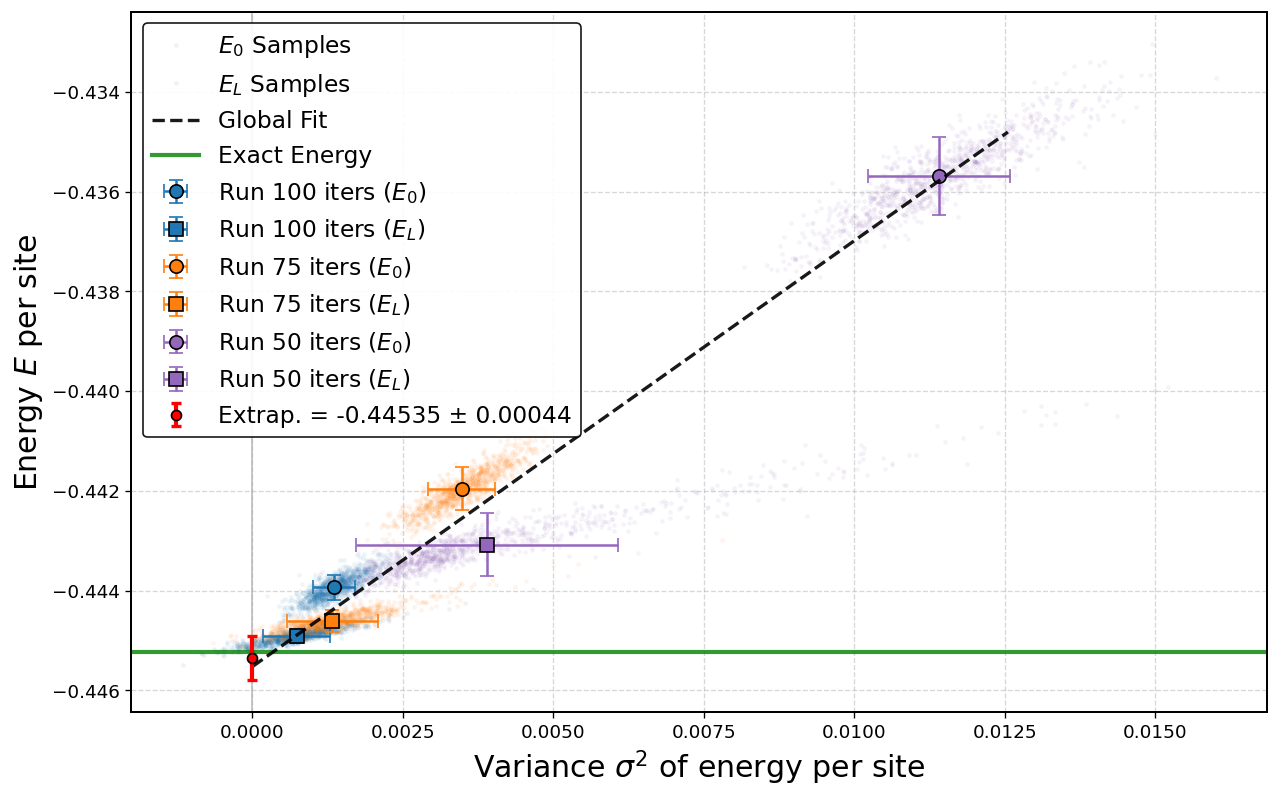

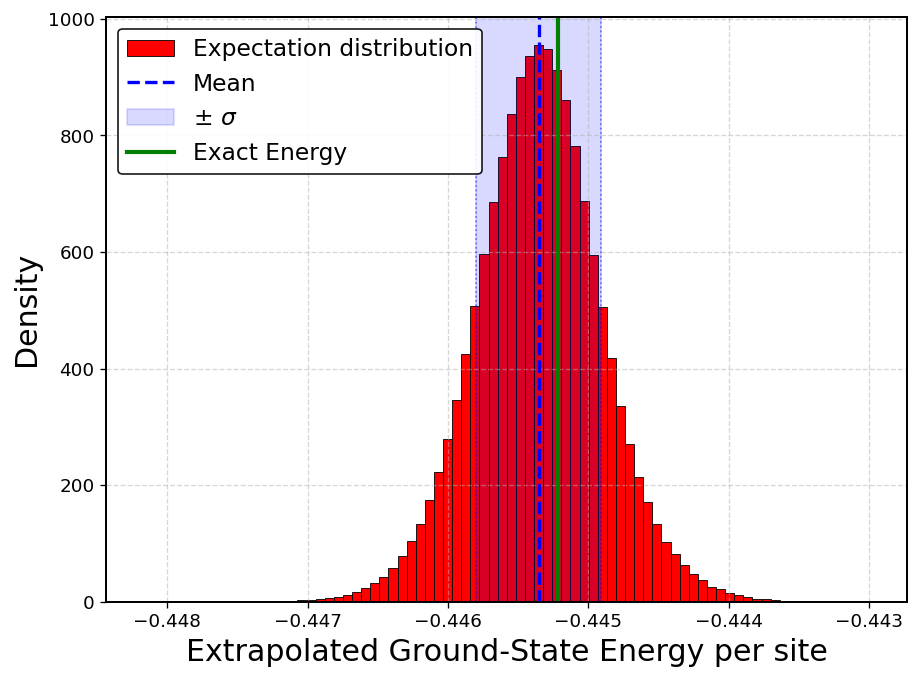

In [6]:
data_dict_AL = load_simulation_data(dossiers, L, verbose=True)
mc_results_AL = run_monte_carlo_extrapolation(data_dict_AL, N_sim, verbose=True)

plot_master_extrapolation(data_dict_AL, mc_results_AL, L, save_dir="../../assets", name="AL_extrapolation")
plot_extrapolation_distribution(data_dict_AL, mc_results_AL, save_dir="../../assets", name="AL_distribution")

In [7]:
df_results = create_results_table(data_dict_AL, L)
print(df_results.to_string(index=False))

 vmc_it  energy VMC  energy lanczos  energy project zero var
     50   -0.435682       -0.443077                -0.446914
     75   -0.441954       -0.444607                -0.446248
    100   -0.443934       -0.444910                -0.446063


## Krylov Subspace 

In [8]:
dossiers = glob.glob("../../datas/datas_krylov_iter_*") 

Loading and processing 3 folders...
✅ Loading complete: 3 simulations processed!
Generating 1000000 synthetic linear regressions...

========== GLOBAL MONTE CARLO RESULTS ==========
Points used for fit       : 6 (3 simulations)
Exact Energy              : -0.44521933
Extrapolated Energy       : -0.44541097 ± 0.00037111
95% Confidence Interval   : [-0.44620145 , -0.44474422]
Absolute Error vs Exact   : 1.92e-04


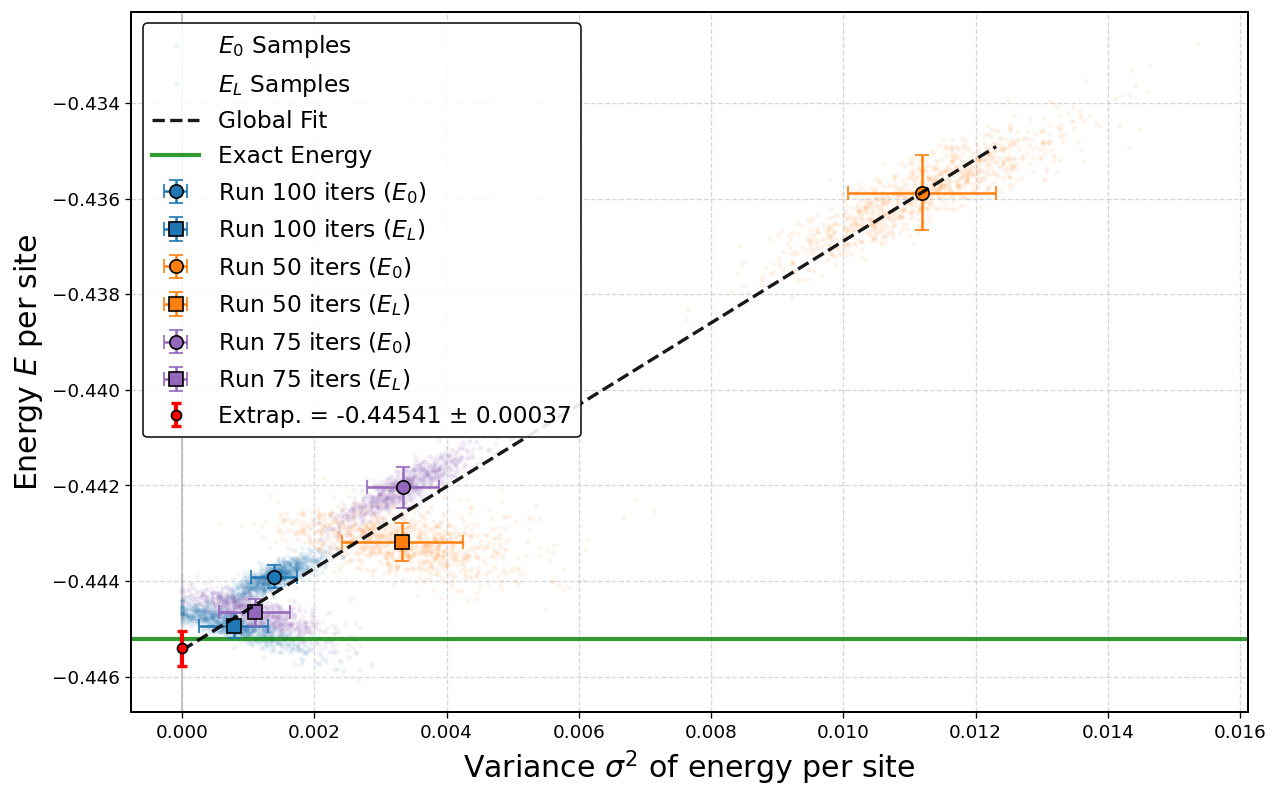

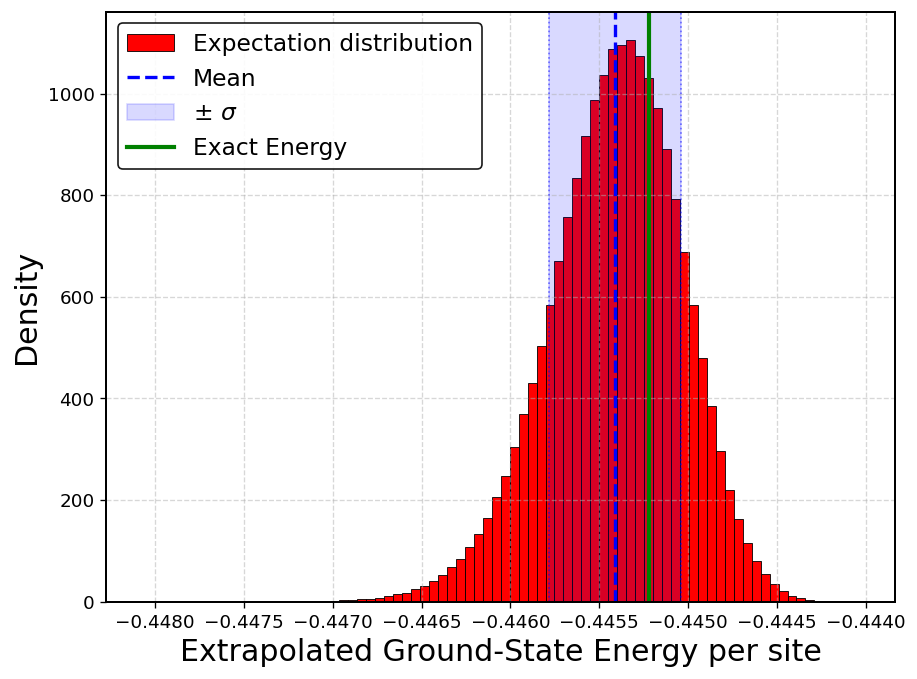

In [9]:
data_dict_KR = load_simulation_data(dossiers, L, verbose=True)
mc_results_KR = run_monte_carlo_extrapolation(data_dict_KR, N_sim, verbose=True)

plot_master_extrapolation(data_dict_KR, mc_results_KR, L, save_dir="../../assets", name="Krylov_extrapolation")
plot_extrapolation_distribution(data_dict_KR, mc_results_KR, save_dir="../../assets", name="Krylov_distribution")

In [10]:
df_results = create_results_table(data_dict_KR, L)
print(df_results.to_string(index=False))

 vmc_it  energy VMC  energy lanczos  energy project zero var
     50   -0.435875       -0.443181                -0.446280
     75   -0.442038       -0.444658                -0.445944
    100   -0.443907       -0.444933                -0.446243


## Comparaison 

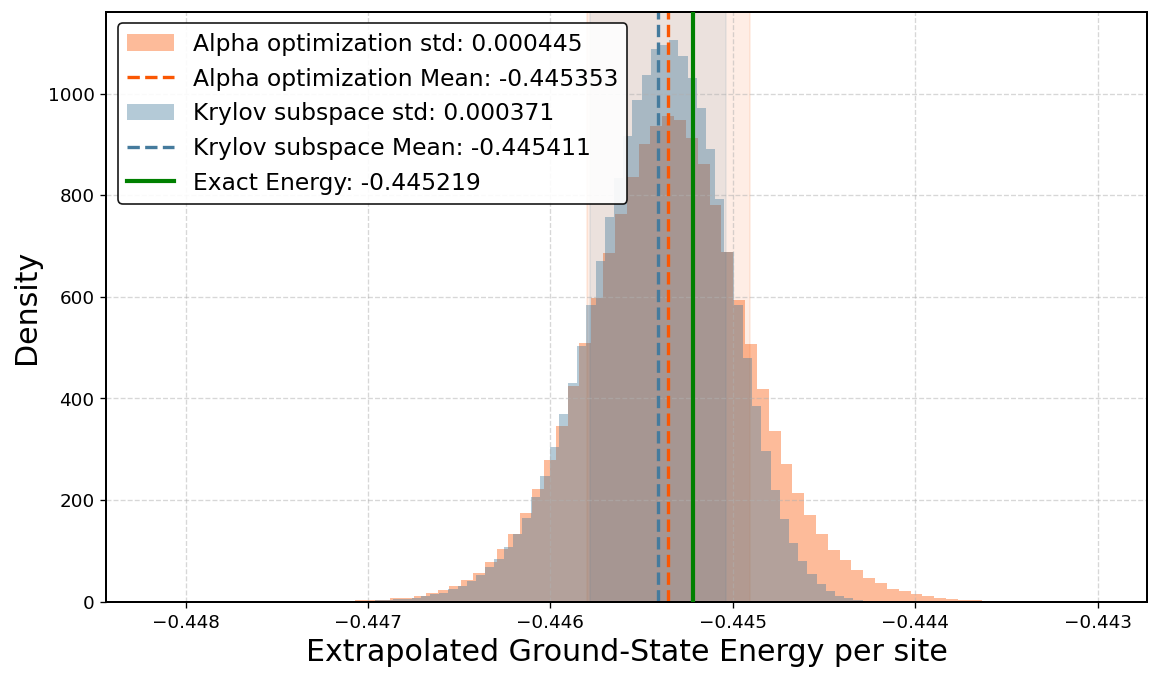

In [11]:
mes_distributions = {
    "Alpha optimization": mc_results_AL,
    "Krylov subspace": mc_results_KR
}

E_exacte = data_dict_AL["exact_gs_energy_per_site"]
plot_multiple_extrapolation_distributions(mes_distributions, E_exacte, save_dir="../../assets")